# TP1 - Protéomique

### 17/09/2025

In [2]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import pandas
import json
from scipy.stats import hypergeom

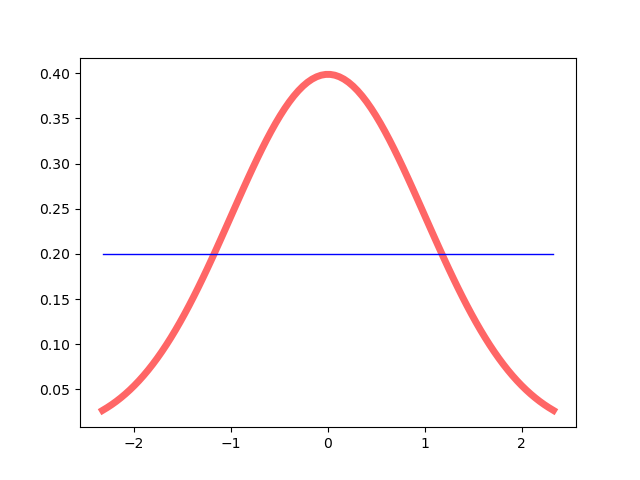

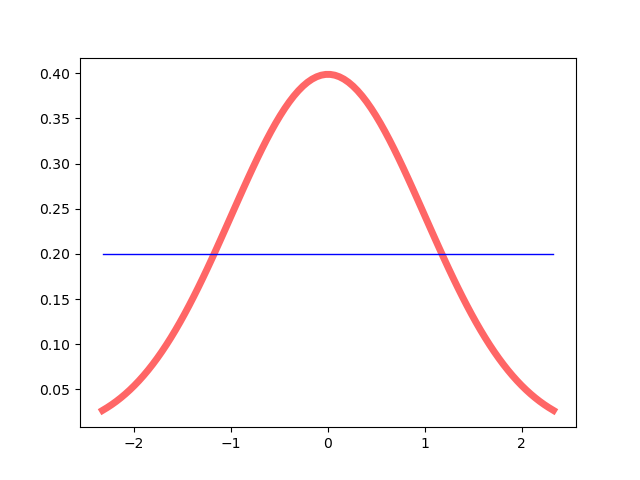

In [3]:
fig, ax = plt.subplots()
x = np.linspace(norm.ppf(0.01),
                norm.ppf(0.99), 100)

ax.plot(x, norm.pdf(x),
       'r-', lw=5, alpha=0.6)

ax.plot(x, np.full(len(x), 0.2),
       'b-', lw=1)

fig.show()

In [4]:
from xml.etree.ElementTree import parse, dump
# Parse the E.Coli proteome XML Document
tree = parse('data/uniprot-proteome_UP000000625.xml')
root = tree.getroot()
ns = '{http://uniprot.org/uniprot}' # MANDATORY PREFIX FOR ANY SEARCH within document
# Store all entries aka proteins in a list of xml nodes
proteins = root.findall(ns + 'entry')
# Display the xml subtree of the first protein 
dump(proteins[0])

<ns0:entry xmlns:ns0="http://uniprot.org/uniprot" dataset="Swiss-Prot" created="1989-10-01" modified="2020-08-12" version="166">
<ns0:accession>P11446</ns0:accession>
<ns0:accession>Q2M8Q3</ns0:accession>
<ns0:name>ARGC_ECOLI</ns0:name>
<ns0:protein>
<ns0:recommendedName>
<ns0:fullName evidence="1 4">N-acetyl-gamma-glutamyl-phosphate reductase</ns0:fullName>
<ns0:shortName evidence="1 4">AGPR</ns0:shortName>
<ns0:ecNumber evidence="1 2">1.2.1.38</ns0:ecNumber>
</ns0:recommendedName>
<ns0:alternativeName>
<ns0:fullName evidence="1 3">N-acetyl-glutamate semialdehyde dehydrogenase</ns0:fullName>
<ns0:shortName evidence="1 3">NAGSA dehydrogenase</ns0:shortName>
</ns0:alternativeName>
</ns0:protein>
<ns0:gene>
<ns0:name type="primary" evidence="1">argC</ns0:name>
<ns0:name type="ordered locus">b3958</ns0:name>
<ns0:name type="ordered locus">JW3930</ns0:name>
</ns0:gene>
<ns0:organism>
<ns0:name type="scientific">Escherichia coli (strain K12)</ns0:name>
<ns0:dbReference type="NCBI Taxonomy" 

In [5]:
# Find the xml subtree of a protein with accession "P31224"
for entry in proteins:
    accessions = entry.findall(ns+"accession")
    for acc in accessions:
        if acc.text == "P31224":
            dump(entry)
            break

<ns0:entry xmlns:ns0="http://uniprot.org/uniprot" dataset="Swiss-Prot" created="1993-07-01" modified="2020-08-12" version="187">
<ns0:accession>P31224</ns0:accession>
<ns0:accession>Q2MBW5</ns0:accession>
<ns0:name>ACRB_ECOLI</ns0:name>
<ns0:protein>
<ns0:recommendedName>
<ns0:fullName>Multidrug efflux pump subunit AcrB</ns0:fullName>
</ns0:recommendedName>
<ns0:alternativeName>
<ns0:fullName>AcrAB-TolC multidrug efflux pump subunit AcrB</ns0:fullName>
</ns0:alternativeName>
<ns0:alternativeName>
<ns0:fullName>Acridine resistance protein B</ns0:fullName>
</ns0:alternativeName>
</ns0:protein>
<ns0:gene>
<ns0:name type="primary">acrB</ns0:name>
<ns0:name type="synonym">acrE</ns0:name>
<ns0:name type="ordered locus">b0462</ns0:name>
<ns0:name type="ordered locus">JW0451</ns0:name>
</ns0:gene>
<ns0:organism>
<ns0:name type="scientific">Escherichia coli (strain K12)</ns0:name>
<ns0:dbReference type="NCBI Taxonomy" id="83333" />
<ns0:lineage>
<ns0:taxon>Bacteria</ns0:taxon>
<ns0:taxon>Proteo

In [6]:
df = pandas.read_csv("data/TCL_wt1.tsv", sep ='\t', na_values="#VALEUR!")

In [7]:
type(df)

pandas.core.frame.DataFrame

In [8]:
df.shape

(2024, 7)

In [9]:
df.head()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
3,P0CE48,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB,NaN,NaN,NaN,NaN
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768


In [10]:
df.tail()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
2019,P24240,6-phospho-beta-glucosidase AscB OS=Escherichia...,ascB,NaN,NaN,NaN,NaN
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579739,0.659686,0.002226,2.652391
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754902,0.811390,0.000068,4.164956
2022,P0AB40,Multiple stress resistance protein BhsA OS=Esc...,bhsA,1.798039,0.846424,0.035928,1.444561
2023,P76042,Putative ABC transporter periplasmic-binding p...,ycjN,NaN,NaN,NaN,NaN


In [11]:
df.columns

Index(['Accession', 'Description', 'Gene Symbol',
       'Corrected Abundance ratio (1.53)', 'Log2 Corrected Abundance Ratio',
       'Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)',
       '-LOG10 Adj.P-val'],
      dtype='object')

In [12]:
df.dtypes

Accession                                                        object
Description                                                      object
Gene Symbol                                                      object
Corrected Abundance ratio (1.53)                                float64
Log2 Corrected Abundance Ratio                                  float64
Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)    float64
-LOG10 Adj.P-val                                                float64
dtype: object

In [13]:
df.info

<bound method DataFrame.info of      Accession                                        Description Gene Symbol  \
0       P75936  Basal-body rod modification protein FlgD OS=Es...        flgD   
1       P76231  Uncharacterized protein YeaC OS=Escherichia co...        yeaC   
2       P0A8S9  Flagellar transcriptional regulator FlhD OS=Es...        flhD   
3       P0CE48  Elongation factor Tu 2 OS=Escherichia coli (st...        tufB   
4       P05706  PTS system glucitol/sorbitol-specific EIIA com...        srlB   
...        ...                                                ...         ...   
2019    P24240  6-phospho-beta-glucosidase AscB OS=Escherichia...        ascB   
2020    P0A917  Outer membrane protein X OS=Escherichia coli (...        ompX   
2021    P02931  Outer membrane protein F OS=Escherichia coli (...        ompF   
2022    P0AB40  Multiple stress resistance protein BhsA OS=Esc...        bhsA   
2023    P76042  Putative ABC transporter periplasmic-binding p...        ycjN

In [14]:
df.describe()

,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
count,1892.000000,1892.000000,1.750000e+03,1750.000000
mean,0.668382,-0.646713,8.238311e-01,0.383981
std,0.184241,0.467234,3.506349e-01,1.066602
min,0.075817,-3.721335,1.034030e-08,0.000000
25%,0.560784,-0.834482,1.000000e+00,0.000000
50%,0.693791,-0.527427,1.000000e+00,0.000000
75%,0.778595,-0.361056,1.000000e+00,0.000000
max,1.798039,0.846424,1.000000e+00,7.985468


In [15]:
df.dropna()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768
5,P29744,Flagellar hook-associated protein 3 OS=Escheri...,flgL,0.124183,-3.009460,0.036746,1.434787
...,...,...,...,...,...,...,...
2011,P77330,Prophage lipoprotein Bor homolog OS=Escherichi...,borD,1.535948,0.619129,0.310725,0.507623
2016,P02930,Outer membrane protein TolC OS=Escherichia col...,tolC,1.552288,0.634396,0.013373,1.873757
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579739,0.659686,0.002226,2.652391
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754902,0.811390,0.000068,4.164956


In [16]:
values = df[['Description', 'Gene Symbol']]

In [17]:
type(values)

pandas.core.frame.DataFrame

In [18]:
values.info

<bound method DataFrame.info of                                             Description Gene Symbol
0     Basal-body rod modification protein FlgD OS=Es...        flgD
1     Uncharacterized protein YeaC OS=Escherichia co...        yeaC
2     Flagellar transcriptional regulator FlhD OS=Es...        flhD
3     Elongation factor Tu 2 OS=Escherichia coli (st...        tufB
4     PTS system glucitol/sorbitol-specific EIIA com...        srlB
...                                                 ...         ...
2019  6-phospho-beta-glucosidase AscB OS=Escherichia...        ascB
2020  Outer membrane protein X OS=Escherichia coli (...        ompX
2021  Outer membrane protein F OS=Escherichia coli (...        ompF
2022  Multiple stress resistance protein BhsA OS=Esc...        bhsA
2023  Putative ABC transporter periplasmic-binding p...        ycjN

[2024 rows x 2 columns]>

In [19]:
values.dtypes

Description    object
Gene Symbol    object
dtype: object

In [20]:
df.head()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
3,P0CE48,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB,NaN,NaN,NaN,NaN
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768


In [21]:
df.iloc[:, -1]

0       4.260067
1       3.454627
2       4.571899
3            NaN
4       1.699768
          ...   
2019         NaN
2020    2.652391
2021    4.164956
2022    1.444561
2023         NaN
Name: -LOG10 Adj.P-val, Length: 2024, dtype: float64

In [22]:
df.iloc[0:4, [0,2,3]]

,Accession,Gene Symbol,Corrected Abundance ratio (1.53)
0,P75936,flgD,0.075817
1,P76231,yeaC,0.092810
2,P0A8S9,flhD,0.102614
3,P0CE48,tufB,NaN


In [23]:
pandas.read_csv('data/TCL_wt1.tsv', sep="\t", na_values="#VALEUR!", dtype = {'Accession': str, 'Description': str, 'Gene Symbol': str, 
                                                 'Corrected Abundance ratio (1.53)': float,  'Log2 Corrected Abundance Ratio': float, 
                                                 'Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)': float, '-LOG10 Adj.P-val': float})

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
3,P0CE48,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB,NaN,NaN,NaN,NaN
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768
...,...,...,...,...,...,...,...
2019,P24240,6-phospho-beta-glucosidase AscB OS=Escherichia...,ascB,NaN,NaN,NaN,NaN
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579739,0.659686,0.002226,2.652391
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754902,0.811390,0.000068,4.164956
2022,P0AB40,Multiple stress resistance protein BhsA OS=Esc...,bhsA,1.798039,0.846424,0.035928,1.444561


In [24]:
df = df.astype({'Log2 Corrected Abundance Ratio': float, '-LOG10 Adj.P-val': float } )

In [25]:
pandas.read_csv('data/TCL_wt1.tsv', sep="\t", na_values="#VALEUR!")

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
3,P0CE48,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB,NaN,NaN,NaN,NaN
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768
...,...,...,...,...,...,...,...
2019,P24240,6-phospho-beta-glucosidase AscB OS=Escherichia...,ascB,NaN,NaN,NaN,NaN
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579739,0.659686,0.002226,2.652391
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754902,0.811390,0.000068,4.164956
2022,P0AB40,Multiple stress resistance protein BhsA OS=Esc...,bhsA,1.798039,0.846424,0.035928,1.444561


In [26]:
df.loc[(df['-LOG10 Adj.P-val'] > 0 )  & (df['Log2 Corrected Abundance Ratio'] > 0.0 ) ]

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
1938,P68919,50S ribosomal protein L25 OS=Escherichia coli ...,rplY,1.010458,0.015009,2.035974e-01,0.691228
1939,P0ACG1,DNA-binding protein StpA OS=Escherichia coli (...,stpA,1.013072,0.018737,1.936673e-01,0.712944
1940,P0A903,Outer membrane protein assembly factor BamC OS...,bamC,1.020915,0.029863,3.957145e-01,0.402618
1945,P0ADE4,Translocation and assembly module subunit TamA...,tamA; ytfM,1.024183,0.034474,2.625522e-03,2.580784
1946,P02943,Maltoporin OS=Escherichia coli (strain K12) OX...,lamB,1.030065,0.042736,3.135847e-03,2.503645
1947,P77774,Outer membrane protein assembly factor BamB OS...,bamB,1.035294,0.050041,4.857703e-01,0.313569
1948,P0A940,Outer membrane protein assembly factor BamA OS...,bamA,1.039869,0.056402,1.228502e-01,0.910624
1955,P0AEQ1,Protein GlcG OS=Escherichia coli (strain K12) ...,glcG,1.050327,0.070838,2.177041e-02,1.662133
1957,P09169,Protease 7 OS=Escherichia coli (strain K12) OX...,ompT,1.052288,0.073529,1.085198e-01,0.964491
1962,P05825,Ferrienterobactin receptor OS=Escherichia coli...,fepA,1.076471,0.106309,1.524348e-02,1.816916


In [27]:
df.loc[ df['Gene Symbol'].isin(['fadR', 'arcA'] ) ]

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
1862,P0A8V6,Fatty acid metabolism regulator protein OS=Esc...,fadR,0.901307,-0.149909,0.000351,3.454627
1898,P0A9Q1,Aerobic respiration control protein ArcA OS=Es...,arcA,0.931373,-0.102570,0.000136,3.866640


In [28]:
df = pandas.read_csv('data/TCL_wt1.tsv', sep="\t", na_values="#VALEUR!")

In [29]:
df.dtypes

Accession                                                        object
Description                                                      object
Gene Symbol                                                      object
Corrected Abundance ratio (1.53)                                float64
Log2 Corrected Abundance Ratio                                  float64
Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)    float64
-LOG10 Adj.P-val                                                float64
dtype: object

In [30]:
df = df.dropna()

In [31]:
df = df.astype({'Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)': float})

In [32]:
df.dtypes

Accession                                                        object
Description                                                      object
Gene Symbol                                                      object
Corrected Abundance ratio (1.53)                                float64
Log2 Corrected Abundance Ratio                                  float64
Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)    float64
-LOG10 Adj.P-val                                                float64
dtype: object

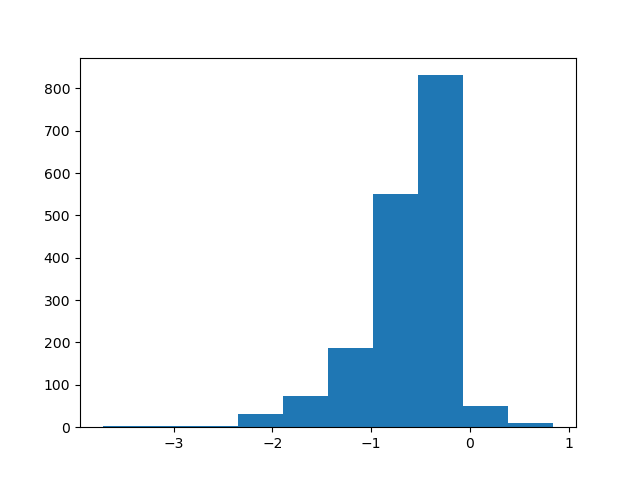

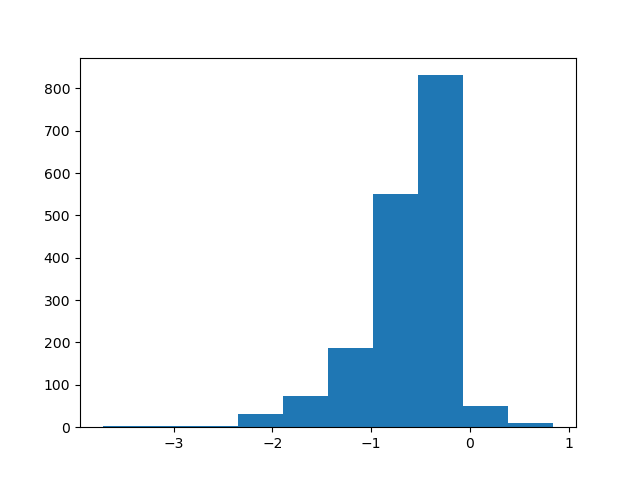

In [33]:
fig, ax = plt.subplots()
ax.hist(df.iloc[:, 4])
fig.show()

In [34]:
mu = np.mean(df.iloc[:, 4])
sigma = np.std(df.iloc[:, 4])
mu, sigma

(-0.63862621564433, 0.47062451611275236)

In [35]:
df.shape

(1746, 7)

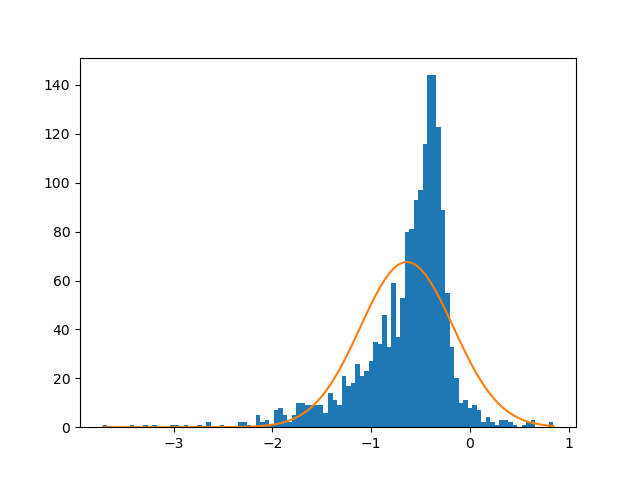

In [36]:
# _ est le vecteur des valeurs d'abondance
fig, ax = plt.subplots()
hist = ax.hist(df.iloc[:, 4], bins=100) # draw histogram
x = np.linspace(min(df.iloc[:, 4]), max(df.iloc[:, 4]), 100) # generate PDF domain points
dx = hist[1][1] - hist[1][0] # Get single value bar height
scale = len(df.iloc[:, 4])*dx # scale accordingly
ax.plot(x, norm.pdf(x, mu, sigma)*scale) # compute theoritical PDF and draw it

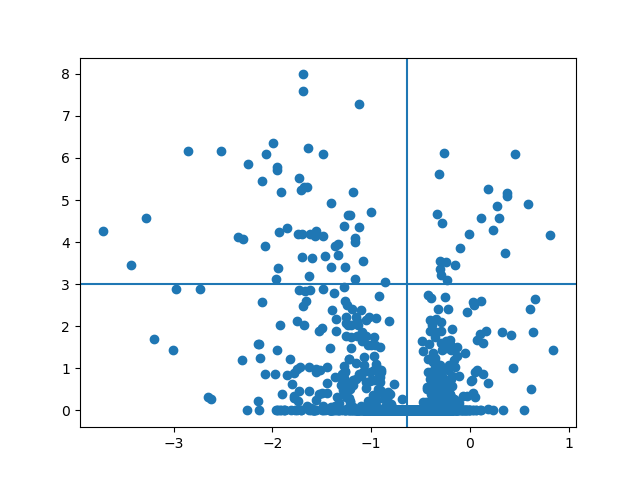

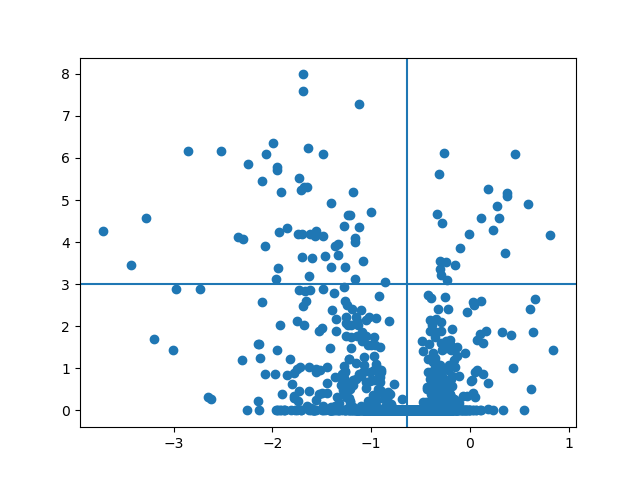

In [37]:
fig, ax = plt.subplots()
ax.scatter(df.iloc[:, 4], df.iloc[:, 6])
ax.axvline(mu)
ax.axhline(-np.log10(0.001))
fig.show()

In [193]:
prot_surab = df.loc[(df['-LOG10 Adj.P-val'] > (-np.log10(0.001)) )  & (df['Log2 Corrected Abundance Ratio'] > mu ) ].iloc[:, 0]
prot_surab = list(prot_surab)
prot_surab, len(prot_surab)

(['P23721',
  'P77804',
  'P0A6K6',
  'P0A799',
  'P0A7G6',
  'P0A6F3',
  'P25745',
  'P0A6M8',
  'P0A6L0',
  'P0A8V6',
  'P0A9Q1',
  'P02358',
  'P0ACF8',
  'P62399',
  'P0A905',
  'P76506',
  'P13036',
  'P10384',
  'P06971',
  'P0A910',
  'P06996',
  'P76344',
  'P02931'],
 23)

In [39]:
from xml.etree.ElementTree import parse, dump

def getAccessionGOTerms(xmlFile, accession):
    tree = parse(xmlFile)
    root = tree.getroot()
    ns = '{http://uniprot.org/uniprot}'
    
    match_go_terms = []
    proteins = root.findall(ns + 'entry')
    for entry in proteins:
        accessions = entry.findall(ns+"accession")
        current_accessions = [ acc.text for acc in accessions ]
        if not accession in current_accessions:
            continue
        goTerms = entry.findall('{http://uniprot.org/uniprot}dbReference[@type="GO"]')
        #goTerms = xmlEntry.findall(ns +'dbReference[@type="GO"]')
        for goT in goTerms:
            gID   = goT.attrib['id']
            gName = goT.find(ns +'property[@type="term"]').attrib['value']
            match_go_terms.append((gID, gName))
        break
    return match_go_terms
getAccessionGOTerms("./data/uniprot-proteome_UP000000625.xml", "P0A8V6")

[('GO:0005829', 'C:cytosol'),
 ('GO:0003677', 'F:DNA binding'),
 ('GO:0003700', 'F:DNA-binding transcription factor activity'),
 ('GO:0000062', 'F:fatty-acyl-CoA binding'),
 ('GO:0019395', 'P:fatty acid oxidation'),
 ('GO:0045892', 'P:negative regulation of transcription, DNA-templated'),
 ('GO:0045723', 'P:positive regulation of fatty acid biosynthetic process'),
 ('GO:0045893', 'P:positive regulation of transcription, DNA-templated'),
 ('GO:0019217', 'P:regulation of fatty acid metabolic process')]

In [40]:
dic_go = {}
for prot in prot_surab :
    go_liste = getAccessionGOTerms("./data/uniprot-proteome_UP000000625.xml", prot)
    for go in go_liste :
        if go[0] not in dic_go.keys() :
            dic_go[go[0]] = {
                'ID' : go[0],
                'name' : go[1],
                'carried_by' : [prot]
            }
        else :
            dic_go[go[0]]['carried_by'].append(prot)   

In [41]:
dic_go

{'GO:0005737': {'ID': 'GO:0005737',
  'name': 'C:cytoplasm',
  'carried_by': ['P23721', 'P0A7G6', 'P0A6M8']},
 'GO:0005829': {'ID': 'GO:0005829',
  'name': 'C:cytosol',
  'carried_by': ['P23721',
   'P0A6K6',
   'P0A799',
   'P0A6F3',
   'P25745',
   'P0A6M8',
   'P0A6L0',
   'P0A8V6',
   'P0A9Q1',
   'P02358',
   'P0ACF8',
   'P62399',
   'P76344']},
 'GO:0004648': {'ID': 'GO:0004648',
  'name': 'F:O-phospho-L-serine:2-oxoglutarate aminotransferase activity',
  'carried_by': ['P23721']},
 'GO:0030170': {'ID': 'GO:0030170',
  'name': 'F:pyridoxal phosphate binding',
  'carried_by': ['P23721']},
 'GO:0006564': {'ID': 'GO:0006564',
  'name': 'P:L-serine biosynthetic process',
  'carried_by': ['P23721']},
 'GO:0006563': {'ID': 'GO:0006563',
  'name': 'P:L-serine metabolic process',
  'carried_by': ['P23721']},
 'GO:0033359': {'ID': 'GO:0033359',
  'name': 'P:lysine biosynthetic process via diaminopimelate and N-succinyl-2-amino-6-ketopimelate',
  'carried_by': ['P23721']},
 'GO:0042823': 

In [42]:
with open('data/EColiK12_GOcounts.json') as file:
    data = json.load(file)
data['go_terms']

{'GO:0000006': {'count': 1,
  'name': 'F:high-affinity zinc transmembrane transporter activity'},
 'GO:0000014': {'count': 4,
  'name': 'F:single-stranded DNA endodeoxyribonuclease activity'},
 'GO:0000015': {'count': 1, 'name': 'C:phosphopyruvate hydratase complex'},
 'GO:0000018': {'count': 4, 'name': 'P:regulation of DNA recombination'},
 'GO:0000025': {'count': 1, 'name': 'P:maltose catabolic process'},
 'GO:0000027': {'count': 27, 'name': 'P:ribosomal large subunit assembly'},
 'GO:0000028': {'count': 20, 'name': 'P:ribosomal small subunit assembly'},
 'GO:0000030': {'count': 1, 'name': 'F:mannosyltransferase activity'},
 'GO:0000032': {'count': 1,
  'name': 'P:cell wall mannoprotein biosynthetic process'},
 'GO:0000034': {'count': 1, 'name': 'F:adenine deaminase activity'},
 'GO:0000035': {'count': 1, 'name': 'F:acyl binding'},
 'GO:0000036': {'count': 1, 'name': 'F:acyl carrier activity'},
 'GO:0000049': {'count': 45, 'name': 'F:tRNA binding'},
 'GO:0000050': {'count': 1, 'name'

In [43]:
len(data['go_terms'].keys())

3901

In [44]:
dic_pval = {}
n = 23
N = 1746

for go in dic_go.keys() :
    K = data['go_terms'][go]['count']
    k = len(dic_go[go]['carried_by'])
    pval = hypergeom.sf(k-1, N, K, n)
    dic_pval[go] = pval
dic_pval

{'GO:0005737': 0.9837534331929435,
 'GO:0005829': 0.6706560686351328,
 'GO:0004648': 0.013172966781214202,
 'GO:0030170': 0.5362094072579163,
 'GO:0006564': 0.051703378215931906,
 'GO:0006563': 0.013172966781214202,
 'GO:0033359': 0.026179856044269836,
 'GO:0042823': 0.051703378215931906,
 'GO:0008615': 0.10084395948147491,
 'GO:0005886': 0.9999999998074859,
 'GO:0042802': 0.4605469513941224,
 'GO:0000287': 0.9252308280163231,
 'GO:0030145': 0.5298103768841498,
 'GO:0008973': 0.026179856044269836,
 'GO:0006015': 0.03902266757579608,
 'GO:0043094': 0.026179856044269836,
 'GO:0006974': 0.03807972332813792,
 'GO:0009264': 0.0001660775181585745,
 'GO:0043531': 0.13609087798767497,
 'GO:0005524': 0.8744576811867714,
 'GO:0004618': 0.013172966781214202,
 'GO:0006094': 0.170013927051803,
 'GO:0006096': 0.2237388071614163,
 'GO:1903862': 0.013172966781214202,
 'GO:0003684': 0.11274303251480405,
 'GO:0008094': 0.12449139765709509,
 'GO:0003697': 0.2543595823011731,
 'GO:0048870': 0.039022667575

In [45]:
sorted(dic_pval, key=dic_pval.get)[:10]

['GO:0009279',
 'GO:0009264',
 'GO:0034220',
 'GO:0046930',
 'GO:0015288',
 'GO:0038023',
 'GO:0015344',
 'GO:0055072',
 'GO:0004648',
 'GO:0006563']

In [46]:
print(dic_pval['GO:0006563'])
print(dic_go['GO:0006563'])

0.013172966781214202
{'ID': 'GO:0006563', 'name': 'P:L-serine metabolic process', 'carried_by': ['P23721']}


### Construction de réseaux d'interactions à partir de données MITAB.

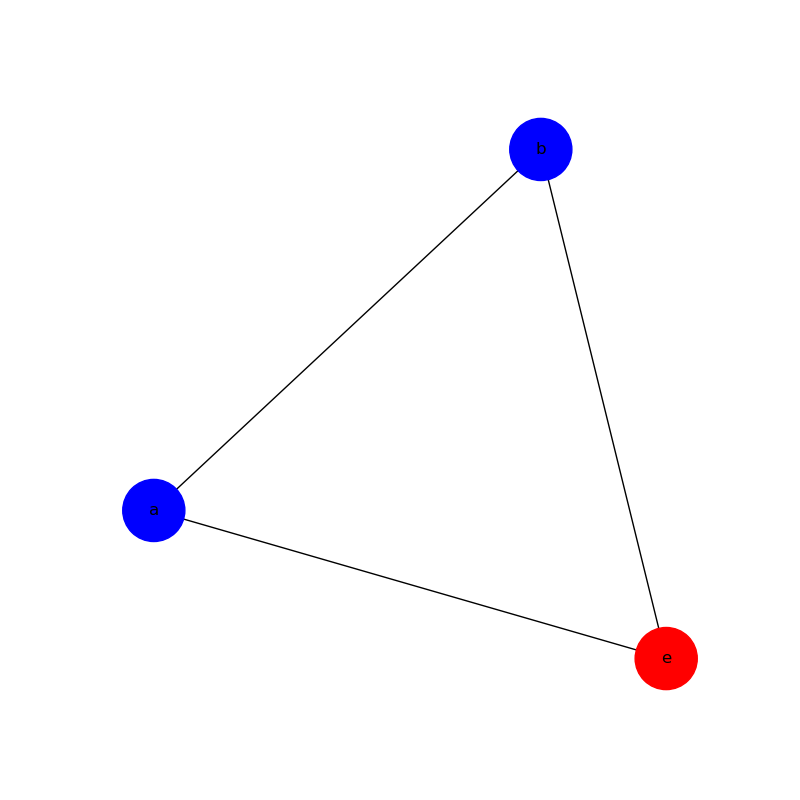

In [98]:
%matplotlib widget
import matplotlib.pyplot as plt
import networkx as nx
G = nx.Graph()

fig, ax = plt.subplots(figsize=(8, 8))

G.add_edge('a', 'b')
G.add_edge('e', 'b')
G.add_edge('e', 'a')
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color=['blue','blue','red'] , node_size=2000)

In [131]:
def parser(mitab_file, uniprot_list) :
    graph = nx.Graph()
    for i in mitab_file :
        print(couple)
        if couple[0] in uniprot_list :
            graph.add_edge(couple[0], couple[1])
        elif couple[1] in uniprot_list :
            graph.add_edge(couple[0], couple[1])
    return graph

In [189]:
import re
def mitab_parser(mitab:str, uniprot_ac:list[str]) ->list[str]:
    hits = []
    with open(mitab) as fp :
        for line in fp :
            line = line.split()
            for proteinfield in line[0:2] : #test column 1 and 2
                _ = re.match("uniprotkb:(\\S+)", proteinfield) #Extract uniprot identifier
                x = _[1] if _ else None
                #print(x)
                if x in uniprot_ac :
                    hits.append(line)
                    break
    print(f"filtered {len(hits)} interactions")
    return hits

In [195]:
df_interactions = mitab_parser("data/proteins.mitab", prot_surab)

filtered 390 interactions


In [183]:
df_interactions[0]

['uniprotkb:P0A6X3',
 'uniprotkb:P02358',
 'intact:EBI-547637|uniprotkb:O24728|uniprotkb:P25521|uniprotkb:Q2M6D3|uniprotkb:Q47383|ensemblbacteria:AAC77129|ensemblbacteria:BAE78173',
 'intact:EBI-543068|uniprotkb:Q2M6A5|ensemblbacteria:AAC77157|ensemblbacteria:BAE78201',
 'psi-mi:hfq_ecoli(display_long)|uniprotkb:hfq(gene',
 'name)|psi-mi:hfq(display_short)|uniprotkb:b4172(locus',
 'name)|uniprotkb:Host',
 'factor-I',
 'protein(gene',
 'name',
 'synonym)|uniprotkb:HF-1(gene',
 'name',
 'synonym)|uniprotkb:JW4130(locus',
 'name)',
 'psi-mi:rs6_ecoli(display_long)|uniprotkb:rpsF(gene',
 'name)|psi-mi:rpsF(display_short)|uniprotkb:Small',
 'ribosomal',
 'subunit',
 'protein',
 'bS6(gene',
 'name',
 'synonym)|uniprotkb:JW4158(locus',
 'name)|uniprotkb:b4200(locus',
 'name)',
 'psi-mi:"MI:0096"(pull',
 'down)',
 'Butland',
 'et',
 'al.',
 '(2005)',
 'pubmed:15690043|mint:MINT-5217509|imex:IM-21967|doi:10.1038/nature03239',
 'taxid:83333(ecoli)|taxid:83333("Escherichia',
 'coli',
 '(strain',


In [280]:
graph = nx.Graph()
list_prot = []
list_colors = []
nb_prot = 0
for interaction in df_interactions :
    x = interaction[0][10:]
    y = interaction[1][10:] 
    graph.add_edge(x, y, data = {"mitab" : interaction})
    for prot in interaction[0:2] :
        if prot not in list_prot :
            list_prot.append(prot)
            uniprot = prot[10:]
            if uniprot in prot_surab :
                list_colors.append("red")
                nb_prot +=1
            else :
                list_colors.append("blue")

In [247]:
nb_prot

15

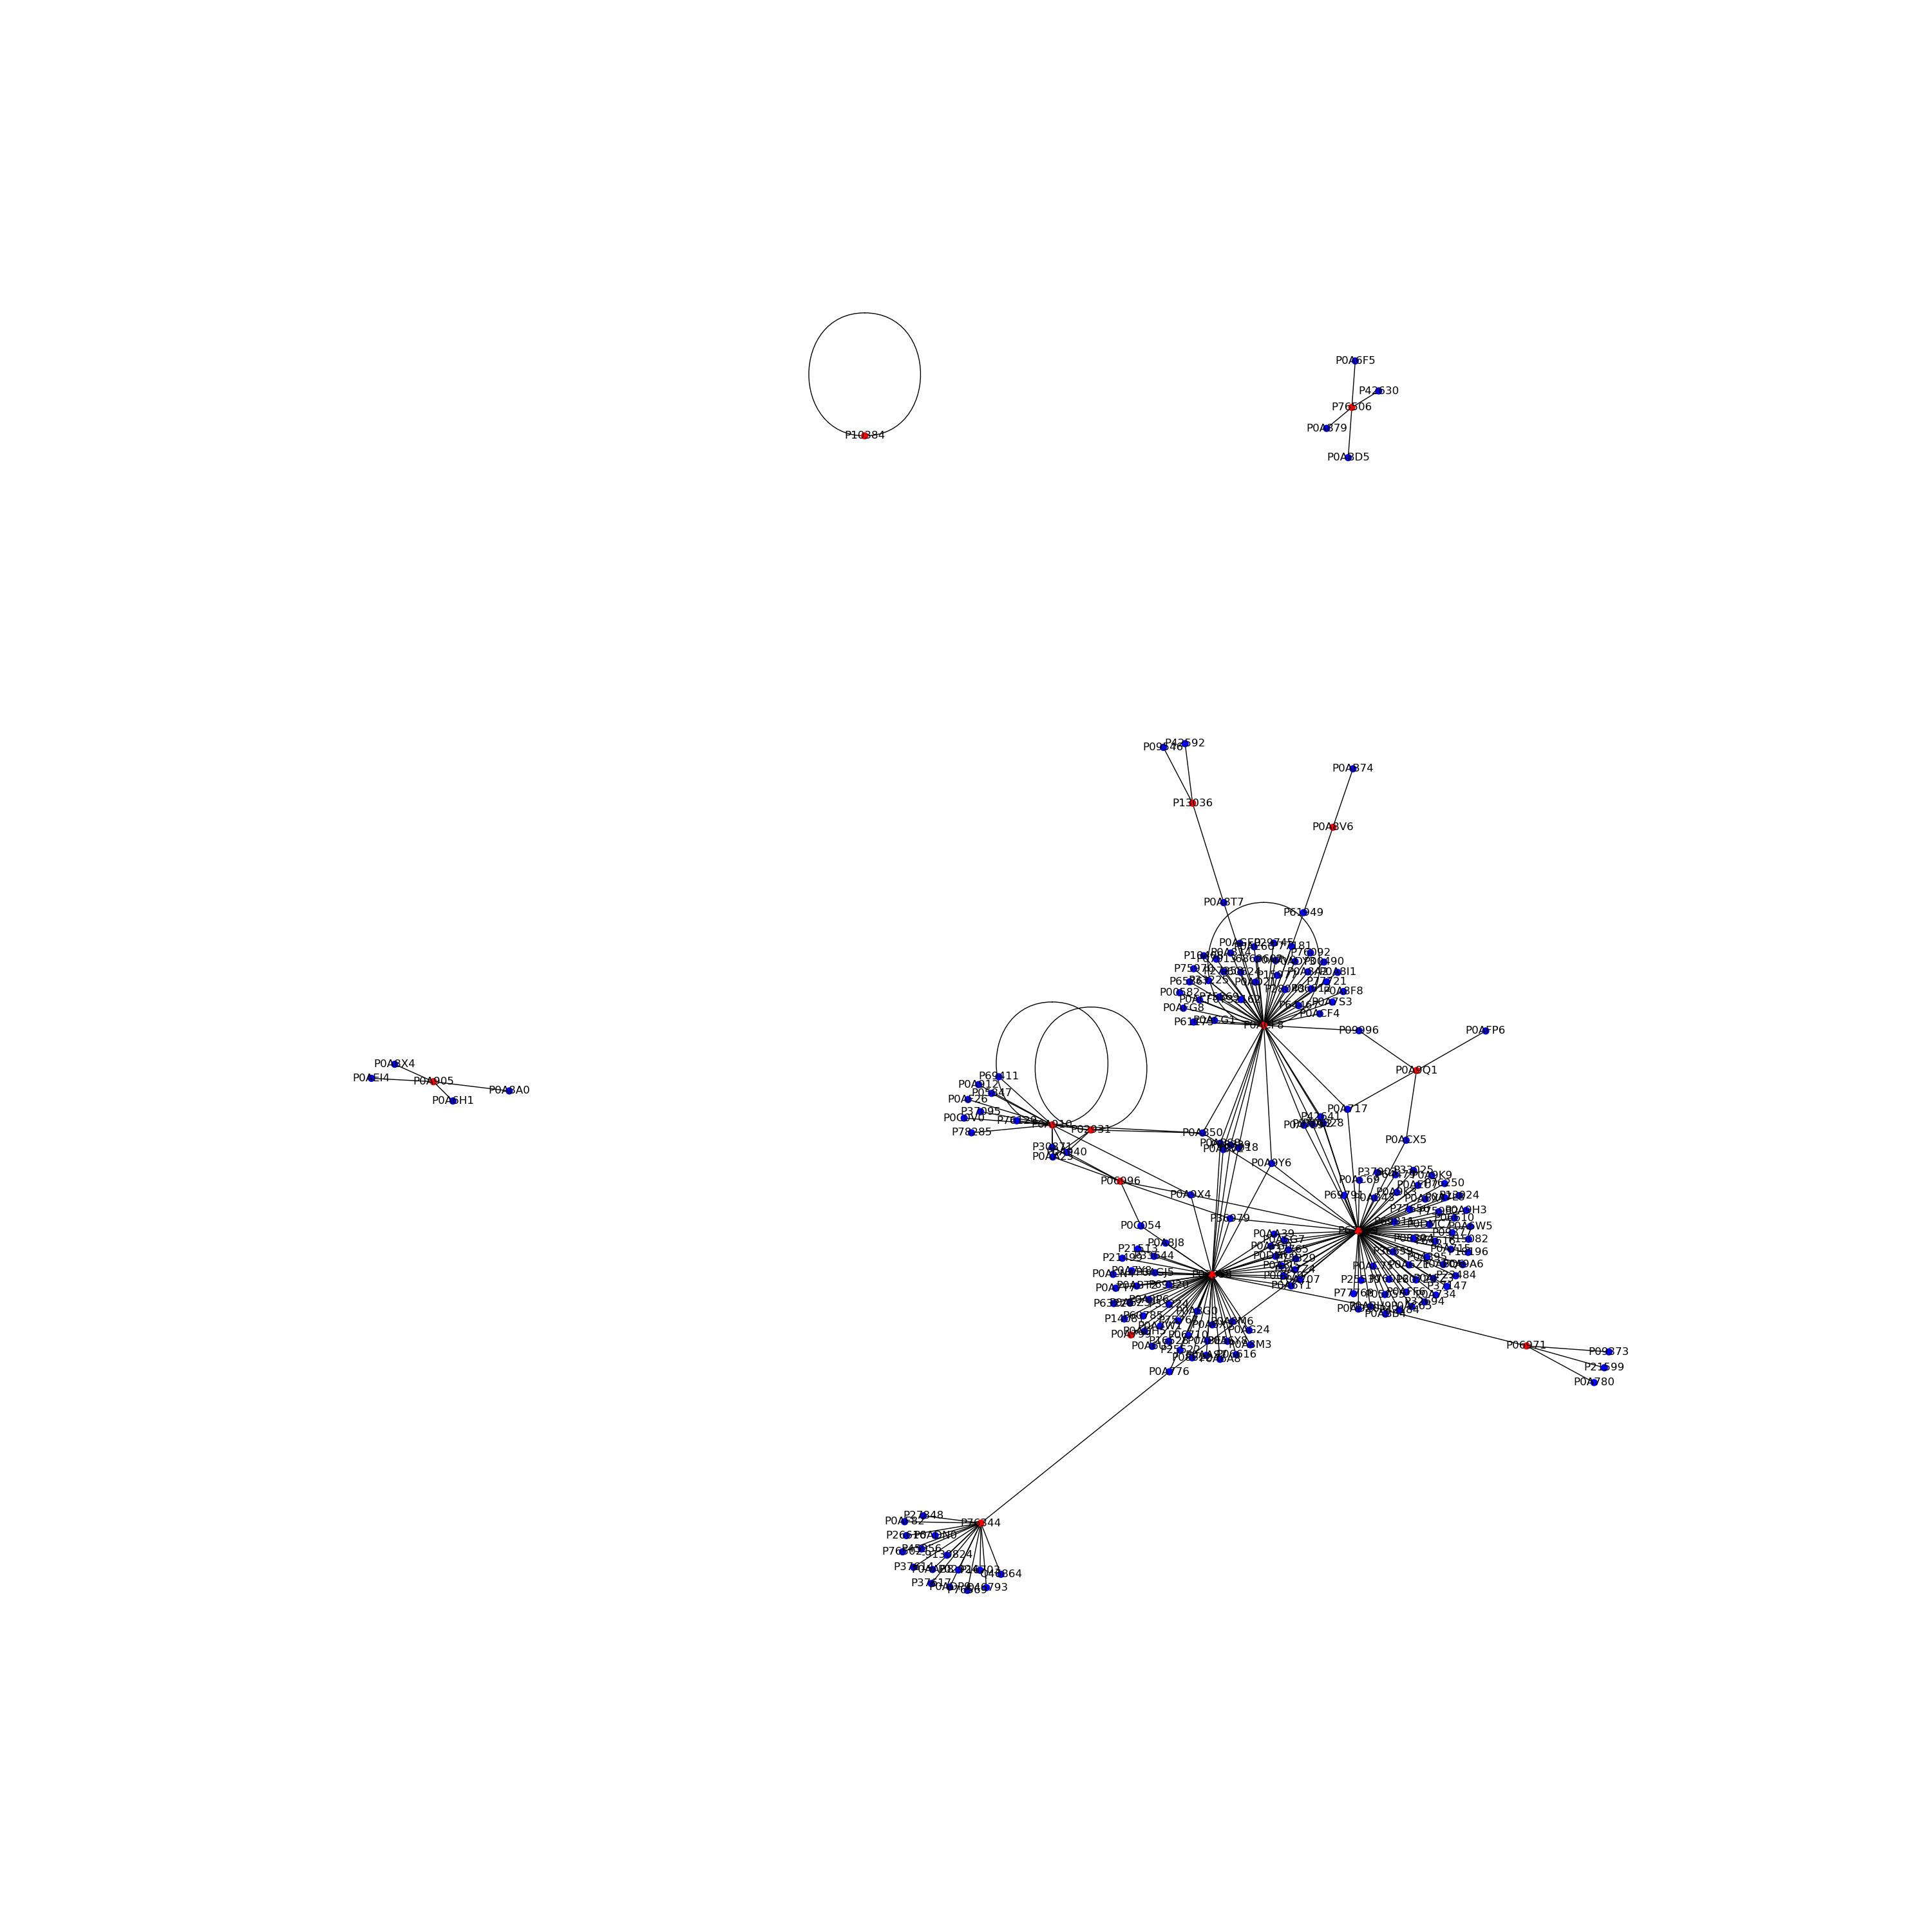

In [286]:
fig, ax = plt.subplots(figsize=(30, 30))
pos = nx.spring_layout(graph)
nx.draw(graph, pos, with_labels=True, node_color=list_colors, node_size=50)

In [276]:
graph_23 = nx.Graph()
list_prot = []
for interaction in df_interactions :
    x = interaction[0][10:]
    y = interaction[1][10:]
    if x in prot_surab and y in prot_surab :
        graph_23.add_edge(x, y, data = {"mitab" : interaction})

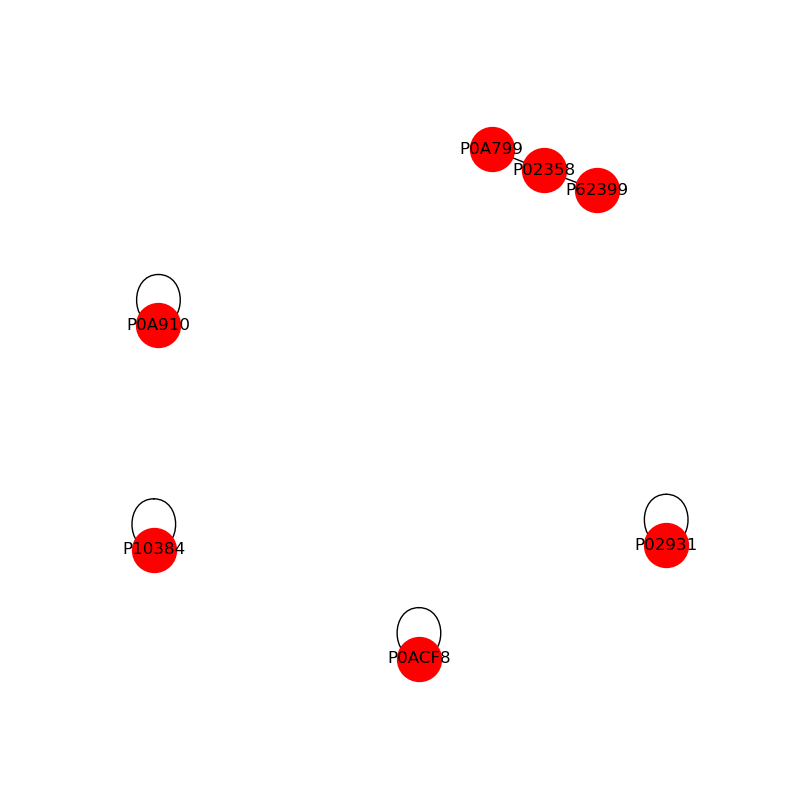

In [288]:
fig, ax = plt.subplots(figsize=(8, 8))
pos = nx.spring_layout(graph_23)
nx.draw(graph_23, pos, node_color="red", with_labels=True, node_size=1000)